In [1]:
using SpecialFunctions
using LinearAlgebra
using Plots, LaTeXStrings
using Struve
using KrylovKit
using SparseArrays
using Arpack  
using QuadGK
using ForwardDiff
using FFTW
using Statistics
using Measures
using Base.Threads
using TensorOperations
include("module_mos2_free_ph_plot.jl")
using .exciton

In [29]:
const FD2_STEPS = [-1,0.0, 1]
const FD2_COEFFS = [-1.0/2.0,0.0, 1.0/2.0]

function bloch_shift(wannier; lattice, Nsample, deltak = 0.2)
	delta_kappa = deltak * lattice.b2 / Nsample # This shifts Bloch function

	newbloch = zeros(eltype(wannier), size(wannier))
	for xv ∈ 1:Nsample, yv ∈ 1:Nsample
		k = (xv * lattice.b1 + yv * lattice.b2) / Nsample

		for xi ∈ 1:Nsample, yi ∈ 1:Nsample
			xi_reduced = periodic_cut_discrete(xi, Nsample, 20)
			yi_reduced = periodic_cut_discrete(yi, Nsample, 20)
			newbloch[xv, yv, :] += wannier[xi, yi, :] * exp(-im * k' * (xi * lattice.R1 + yi * lattice.R2)) * exp(-im * delta_kappa' * (xi_reduced * lattice.R1 + yi_reduced * lattice.R2))
		end
	end

	return newbloch
end

function periodic_cut_discrete(x::Integer, L::Integer, cutoff)
	halfL = div(L, 2)  # integer division
	# Wrap x into [-halfL, L - halfL - 1] for odd L
	y = mod1(x, L)
	if y > halfL
		y -= L
	end
	return abs(y) <= cutoff ? y : 0
end

function TMD_jx_6th(k; epsilonyy, sz, deltax = 0.1)
	kx, ky = k
	h = deltax
	f(x) = exciton.TMD_hnn((x, ky); epsilonyy, sz)

	return -(f(kx - 3h) - 9f(kx - 2h) + 45f(kx - h) - 45f(kx + h) + 9f(kx + 2h) - f(kx + 3h)) / (60h)
end

function TMD_jy_6th(k; epsilonyy, sz, deltay = 0.1)
	kx, ky = k
	h = deltay
	f(y) = exciton.TMD_hnn((kx, y); epsilonyy, sz)

	return -(f(ky - 3h) - 9f(ky - 2h) + 45f(ky - h) - 45f(ky + h) + 9f(ky + 2h) - f(ky + 3h)) / (60h)
end

function bse_kernel_construction(newbv, newbc1, newbc2, Nsample; VInt, epsilonyy, sz = 1, deltak, lattice)
	V = VInt.V
	# Precompute all Hamiltonian indices
	ham_indices = Array{Int}(undef, Nsample, Nsample, 2)
	for kx in 1:Nsample, ky in 1:Nsample, k_cond_ind in 1:2
		ham_indices[kx, ky, k_cond_ind] = ham_index(kx, ky, k_cond_ind; xlength = Nsample, ylength = Nsample)
	end

	ham = zeros(ComplexF64, Nsample^2 * 2, Nsample^2 * 2)
	conductions = [newbc1, newbc2]

	# Coulomb part
	for kx in 1:Nsample, ky in 1:Nsample, k_cond_ind in 1:2
		kidx = ham_indices[kx, ky, k_cond_ind]
		for kxp in 1:Nsample, kyp in 1:Nsample, kp_cond_ind in 1:2
			kpidx = ham_indices[kxp, kyp, kp_cond_ind]

			ck = conductions[k_cond_ind][kx, ky, :]
			ckp = conductions[kp_cond_ind][kxp, kyp, :]

			vk = newbv[kx, ky, :]
			vkp = newbv[kxp, kyp, :]
			qx, qy = mod1.([kxp - kx, kyp - ky], Nsample)
			ham[kidx, kpidx] += -(ck' * ckp) * (vkp' * vk) * V[qx, qy] / Nsample^2 #
		end
	end

	# Add ecvmat contribution (same k)
	for kx in 1:Nsample, ky in 1:Nsample
		kvec = (kx * lattice.b1 + (ky+deltak) * lattice.b2) / Nsample
		hkmat = exciton.TMD_hnn(kvec; epsilonyy, sz)
		c1 = newbc1[kx, ky, :]
		c2 = newbc2[kx, ky, :]
		v = newbv[kx, ky, :]
		ev = v' * hkmat * v

		ecvmat = [c1'*hkmat*c1-ev c1'*hkmat*c2; c2'*hkmat*c1 c2'*hkmat*c2-ev]
		for k_cond_ind in 1:2, kp_cond_ind in 1:2
			kidx = ham_indices[kx, ky, k_cond_ind]
			kpidx = ham_indices[kx, ky, kp_cond_ind]
			ham[kidx, kpidx] += ecvmat[k_cond_ind, kp_cond_ind]
		end
	end

	return ham

end


"""
Helper: Shifts a wavefunction by multiple steps of dk.
"""
function generate_shifted_bloch(w, lattice, Nsample, dk, steps)
	return [bloch_shift(w; lattice, Nsample, deltak = s * dk) for s in steps]
end

"""
Helper: Solves the BSE for a specific k-shift to get the Envelope Function (Psi).
"""
function solve_bse_at_shift(bv, bc1, bc2, Nsample, VInt, epsilonyy, shift_idx, dk, state_idx; lattice)
	# Calculate actual deltak for the kernel construction
	current_deltak = FD2_STEPS[shift_idx] * dk

	bsemat = bse_kernel_construction(bv, bc1, bc2, Nsample;
		VInt, epsilonyy, sz = 1, deltak = current_deltak, lattice)

	xlen = size(bsemat)[1]
	x0 = rand(xlen)

	# Solve Eigenproblem
	valslist, vecslist, _ = eigsolve(bsemat, x0, 20, :SR,
		krylovdim = 120, tol = 1e-10, maxiter = 40,
		verbosity = 0, ishermitian = true)

	# Extract specific state and energy
	return vecslist[state_idx], valslist[1]
end

"""
Helper: Enforces phase continuity (U(1) gauge fixing) across the list of Psis.
"""
function fix_gauge!(psi_list)
	for n in 1:(length(psi_list)-1)
		overlap = dot(psi_list[n], psi_list[n+1])
		if abs(overlap) > 1e-12
			phase = overlap / abs(overlap) # e^{iθ}
			# Rotate n+1 to match n
			psi_list[n+1] .*= conj(phase)
		end
	end
end

"""
Term 1: Derivative of the Optical Matrix Element Phase (Wilson Line).
"""
function compute_optical_phase_deriv(bv_list, bc1_list, bc2_list, psi_list,
	lattice, Nsample, dk, polarization, epsilonyy, sz)

	phases = zeros(Float64, length(FD2_STEPS))

	for (i, step_mult) in enumerate(FD2_STEPS)
		pump_sum = ComplexF64(0.0)

		# Grid loop
		for xdim ∈ 1:Nsample, ydim ∈ 1:Nsample
			# Calculate k for current shift
			k = (xdim * lattice.b1 + (ydim + dk * step_mult) * lattice.b2) / Nsample

			# Dipole operators
			jx = TMD_jx_6th(k; epsilonyy, sz)
			jy = TMD_jy_6th(k; epsilonyy, sz)
			j_op = polarization[1] * jx + polarization[2] * jy

			# Indices
			p1_idx = ham_index(xdim, ydim, 1; xlength = Nsample, ylength = Nsample)
			p2_idx = ham_index(xdim, ydim, 2; xlength = Nsample, ylength = Nsample)

			# Wavefunctions at this grid point
			v = bv_list[i][xdim, ydim, :]
			c1 = bc1_list[i][xdim, ydim, :]
			c2 = bc2_list[i][xdim, ydim, :]

			# Optical transition elements weighted by Envelope Psi
			pump_sum += (v' * j_op * c1) * psi_list[i][p1_idx]
			pump_sum += (v' * j_op * c2) * psi_list[i][p2_idx]
		end
		phases[i] = angle(pump_sum)
	end

	# Apply 4th order finite difference to the scalar phases
	deriv = sum(phases .* FD2_COEFFS)
	return deriv
end

"""
Term 2: Berry Connection of the Bloch Bands projected onto Envelope.
Term 3: Derivative of the Envelope Function (Psi).
"""
function compute_berry_terms(bv_list, bc1_list, bc2_list, psi_list, Nsample)

	# Indices for the center point (k) within the lists
	center_idx = findfirst(x -> x == 0, FD2_STEPS) # Should be 3

	# Pre-fetch center wavefunctions
	v_center = bv_list[center_idx]
	c1_center = bc1_list[center_idx]
	c2_center = bc2_list[center_idx]
	psi_center = psi_list[center_idx]

	term2 = ComplexF64(0.0)

	# We need to compute <u(k) | d/dk | u(k)>.
	# d/dk u(k) approx sum(coeffs[j] * u(k+j*dk))

	for kx ∈ 1:Nsample, ky ∈ 1:Nsample
		# 1. Compute Finite Difference Derivatives of Bloch functions at k (center)
		# Initialize derivatives as zero vectors
		dv = zeros(ComplexF64, length(v_center[kx, ky, :]))
		dc1 = zeros(ComplexF64, length(c1_center[kx, ky, :]))
		dc2 = zeros(ComplexF64, length(c2_center[kx, ky, :]))

		for (j, coeff) in enumerate(FD2_COEFFS)
			dv .+= coeff .* bv_list[j][kx, ky, :]
			dc1 .+= coeff .* bc1_list[j][kx, ky, :]
			dc2 .+= coeff .* bc2_list[j][kx, ky, :]
		end

		# 2. Compute Berry Connections A = i <u | du> (un-normalized by dk here, handled in coeffs)
		# Note: These are scalar values for specific kx, ky
		Av = im * dot(v_center[kx, ky, :], dv)
		Ac11 = im * dot(c1_center[kx, ky, :], dc1)
		Ac12 = im * dot(c1_center[kx, ky, :], dc2)
		Ac21 = im * dot(c2_center[kx, ky, :], dc1)
		Ac22 = im * dot(c2_center[kx, ky, :], dc2)

		# 3. Project onto Envelope Function (Psi)
		p1 = ham_index(kx, ky, 1; xlength = Nsample, ylength = Nsample)
		p2 = ham_index(kx, ky, 2; xlength = Nsample, ylength = Nsample)

		psi1 = psi_center[p1]
		psi2 = psi_center[p2]

		term2 += (Ac11 - Av) * conj(psi1) * psi1
		term2 += (Ac12) * conj(psi1) * psi2
		term2 += (Ac21) * conj(psi2) * psi1
		term2 += (Ac22 - Av) * conj(psi2) * psi2
	end

	# Term 3: Envelope Derivative <Psi | d/dk | Psi>
	# d/dk Psi approx sum(coeffs[j] * Psi[j])
	dPsi = zeros(ComplexF64, length(psi_center))
	for (j, coeff) in enumerate(FD2_COEFFS)
		dPsi .+= coeff .* psi_list[j]
	end

	term3 = im * dot(psi_center, dPsi)

	return term2, term3
end

# --- Main Subroutine ---

function exciton_subroutine_4th(wv, wc1, wc2; state = 1, polarization = [[cos(pi / 3), sin(pi / 3)]], VInt, lattice, epsilonyy, sz = 1, Nsample)

	dk = 0.01

	# 1. Generate Shifted Bloch Functions (5 points: -2dk to +2dk)
	bv_list = generate_shifted_bloch(wv, lattice, Nsample, dk, FD2_STEPS)
	bc1_list = generate_shifted_bloch(wc1, lattice, Nsample, dk, FD2_STEPS)
	bc2_list = generate_shifted_bloch(wc2, lattice, Nsample, dk, FD2_STEPS)

	# 2. Compute Envelope Functions (Psi) for each shift
	psi_list = Vector{Vector{ComplexF64}}(undef, length(FD2_STEPS))

	#   println("Starting Diagonalization...")
	for i in 1:length(FD2_STEPS)
		psi, val = solve_bse_at_shift(bv_list[i], bc1_list[i], bc2_list[i],
			Nsample, VInt, epsilonyy, i, dk, state; lattice)
		psi_list[i] = psi
		if i == 2 # Center point
			println("Center Energy: ", val)
		end
	end
	#  println("Finish computing envelope functions")

	# 3. Gauge Fixing (Critical for derivatives)
	# We copy to preserve raw data if needed, though strictly not necessary if memory is abundant
	psi_list_gauge_fixed = deepcopy(psi_list)
	fix_gauge!(psi_list_gauge_fixed)

	# 4. Compute Derivatives
	# Normalization factor for derivative: 1 / (dk * |b2|/Nsample)
	dk_norm = (dk * norm(lattice.b2) / Nsample)

	# A. Optical Phase Derivative (Wilson-like term)
	# The coeffs are applied inside, so result is d(Angle)/d(Step)
	#   term1_val = compute_optical_phase_deriv(bv_list, bc1_list, bc2_list, psi_list_gauge_fixed,
	#       lattice, Nsample, dk, polarization, epsilonyy, sz)

	# B. Berry Connections and Envelope Derivative
	# These return raw sums weighted by coeffs. We must divide by dk_norm at the end.
	term2_val, term3_val = compute_berry_terms(bv_list, bc1_list, bc2_list, psi_list_gauge_fixed, Nsample)

	rtot_list = Vector{ComplexF64}(undef, length(polarization))

	for (j, pol) in pairs(polarization)

		# Term 1 for this polarization
		term1_val = compute_optical_phase_deriv(
			bv_list, bc1_list, bc2_list, psi_list_gauge_fixed,
			lattice, Nsample, dk, pol, epsilonyy, sz
		)

		# rtot(j)
		rtot_list[j] = (term1_val + term2_val + term3_val) / dk_norm
	end

	println("rtot for all polarizations: ", rtot_list)

	# Sum and Normalize
	# FD4_COEFFS assumes sum(c_i * f_i), so we divide by the step size (dk_norm) once.
	#   rtot = (term1_val + term2_val + term3_val) / dk_norm

	return rtot_list
end


println("Start calculation")
Nsample=60
sz = 1
lattice = GrapheneLattice();
#VInt = InteractionMatrix(lattice, Nsample; lambda=0.8, r0=4.28)
VInt = InteractionMatrix(lattice, Nsample; lambda = 0.667, r0 = 4.288)
bi_1 = lattice.b1 / Nsample
bi_2 = lattice.b2 / Nsample
bi_3 = -bi_1 - bi_2
wb = 2 / (3 * norm(bi_1)^2)

# --- CRITICAL PERFORMANCE SETTING ---
# We force linear algebra to be single-threaded so our 4 Julia threads
# can run on independent cores without fighting for resources.
BLAS.set_num_threads(1)

Start calculation


## Fig. 3c

In [79]:
kx = 4pi / 3
ky = 0
θ = 0:0.1:2pi

strainlist = collect(-3.0:0.2:3.0)

rshift1 = similar(strainlist)
rshift2 = similar(strainlist)
rshift3 = similar(strainlist)
rshift4 = similar(strainlist)

for (i, strain_val) in enumerate(strainlist)
    th = -(sqrt((1 + strain_val / 100)^2 * 3 / 4 + 1 / 4) - 1) * 5

    kdir = [cos(0), sin(0)]
    rcv_shift = imag.(exciton.shiftvec([kx, ky], kdir; epsilonyy=th, sz=1))
    rcvnorm = exciton.norm_elem([kx, ky], kdir; epsilonyy=th, sz=1)

    rshift1[i] = rcv_shift[2] / rcvnorm

    kdir = [cos(pi/6), sin(pi/6)]
    rcv_shift = imag.(exciton.shiftvec([kx, ky], kdir; epsilonyy=th, sz=1))
    rcvnorm = exciton.norm_elem([-kx, ky], kdir; epsilonyy=th, sz=1)
    rshift2[i] = rcv_shift[2] / rcvnorm

    kdir = [cos(pi / 2), sin(pi / 2)]
    rcv_shift = imag.(exciton.shiftvec([kx, ky], kdir; epsilonyy=th, sz=1))
    rcvnorm = exciton.norm_elem([kx, ky], kdir; epsilonyy=th, sz=1)
    rshift3[i] = rcv_shift[2] / rcvnorm

end

rshift1_3=copy(rshift1)
rshift2_3=copy(rshift2)
rshift3_3=copy(rshift3)
strainlist_3=copy(strainlist);

hline([0], color=:black, lw=0.5, label=false, xlim=(-3.1, 3.1), xticks=([-3,-2,-1 ,0, 1,2,3]))

# Vertical axis at x = 0
vline!([0], color=:black, lw=0.5, label=false)
#scatter!(strainlist_3, [rshift1_3 rshift2_3 rshift3_3] .* 100, framestyle=:box, xgrid=false, ylim=(-7, 7), legendfontsize=7, yticks=([-6, -3, 0, 3, 6]), ygrid=false,lw=3, label=[L"K, \theta=0,S_z=+1/2" L"K', \theta=0,S_z=+1/2" L"K, \theta=\pi/2,S_z=+1/2"],ls=[:dash :solid :dashdot], tickfontsize=15, dpi=800, size=(360, 320))
#color = [:red :blue :green :orange],
scatter!(strainlist_3, [rshift1_3 rshift2_3 rshift3_3] .* 100, framestyle=:box, xgrid=false, ylim=(-7, 7), legendfontsize=7, yticks=([-6, -3, 0, 3, 6]), ygrid=false,markersize=3, label=[L"\theta=0" L"\theta=\pi/6" L"\theta=\pi/2"], tickfontsize=10, dpi=800, size=(420, 320))

savefig("fig3c.png")

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3c.png"

## Fig. 3c (inset)

In [177]:
kx = 4pi / 3
ky = 0
θlist = 0:0.1:pi

# Preallocate result array
rshift1 = zeros(Float64,length(θlist))
strain_val=0

for (i, theta) in enumerate(θlist)
    th = -(sqrt((1 + strain_val / 100)^2 * 3 / 4 + 1 / 4) - 1) * 5

    kdir = [cos(theta), sin(theta)]
    rcv_shift = imag.(exciton.shiftvec([kx, ky], kdir; epsilonyy=th, sz=1))
    rcvnorm = exciton.norm_elem([kx, ky], kdir; epsilonyy=th, sz=1)
    rshift1[i] = rcv_shift[2] / rcvnorm
end

rshift1_3a=copy(rshift1)
θlist_3a=copy(θlist);


rshift1 = zeros(Float64,length(θlist))
strain_val=1

for (i, theta) in enumerate(θlist)
    th = -(sqrt((1 + strain_val / 100)^2 * 3 / 4 + 1 / 4) - 1) * 5

    kdir = [cos(theta), sin(theta)]
    rcv_shift = imag.(exciton.shiftvec([kx, ky], kdir; epsilonyy=th, sz=1))
    rcvnorm = exciton.norm_elem([kx, ky], kdir; epsilonyy=th, sz=1)
    rshift1[i] = rcv_shift[2] / rcvnorm
end

rshift1_3a2=copy(rshift1)
θlist_3a2=copy(θlist);

hline([0], color=:black, lw=0.5, label=false, xlim=(-0.1, pi+0.1), xticks=([0, pi/2,pi],["0", L"\pi/2", L"\pi"]))

# Vertical axis at x = 0
#vline!([0], color=:black, lw=0.5, label=false)
#scatter!(θlist_3a, rshift1_3a .* 100, framestyle=:box, xgrid=false, ylim=(-1.5, 1.5), legendfontsize=17, yticks=([-1, 0, 1]), ygrid=false, label=L"K, S_z=+1/2", tickfontsize=25, dpi=800, size=(300, 300))
scatter!(θlist_3a, rshift1_3a .* 100, framestyle=:box, xgrid=false, legendfontsize=17, yticks=([-1, 0, 1,2,3]), ygrid=false, label="strain 0", tickfontsize=20, dpi=800, size=(380, 300))
scatter!(θlist_3a2, rshift1_3a2 .* 100, framestyle=:box, xgrid=false, ylim=(-1.2, 4), legendfontsize=13, ygrid=false, label="strain 1%", tickfontsize=20, dpi=800, size=(380, 300),legend=:topleft)

savefig("fig3cinset.png")

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3cinset.png"

In [157]:
rshift1_3a2*100

32-element Vector{Float64}:
 1.5357217368879137
 1.5407125167601021
 1.5555080771429162
 1.5795818599469724
 1.6120691545805421
 1.6517873776163787
 1.6972661655110202
 1.7467885253785616
 1.798444022277753
 1.8501943134587442
 1.8999502748702843
 1.9456585805840507
 1.9853940528084
 ⋮
 1.9630148250538701
 1.9195675321739265
 1.8712509049607269
 1.8200763536071238
 1.7681290606987798
 1.717478465663871
 1.6700968595358998
 1.6277888640154965
 1.5921330939473246
 1.5644360901653251
 1.5456977721167724
 1.536587229562243

## Fig 3d

In [64]:
Nsample=60
lattice = GrapheneLattice();
#VInt = InteractionMatrix(lattice, Nsample; lambda=0.8, r0=4.28)
VInt = InteractionMatrix(lattice, Nsample; lambda=0.667, r0=4.288)
bi_1 = lattice.b1 / Nsample
bi_2 = lattice.b2 / Nsample
bi_3 = -bi_1 - bi_2
wb = 2 / (3 * norm(bi_1)^2)
strainlist = collect(-3:0.06:3)

fulllist = Vector{Vector{ComplexF64}}(undef, length(strainlist))

for (i, strain_val) in enumerate(strainlist)
    epsilonyy = -(sqrt((1 + strain_val / 100)^2 * 3 / 4 + 1 / 4) - 1) * 5
    println("This is $epsilonyy")
    graphene_sys = GrapheneBSE(lattice, [0.0, 0], Nsample; sz=1, epsilonyy)
    bloch_v, bloch_c1, bloch_c2 = graphene_sys.Bloch.valence, graphene_sys.Bloch.conduction1, graphene_sys.Bloch.conduction2
    bloch_states = [bloch_v]
    M_b1 = exciton.compute_M_matrix(bloch_states, (1, 0))
    M_b2 = exciton.compute_M_matrix(bloch_states, (0, 1))
    M_b3 = exciton.compute_M_matrix(bloch_states, (-1, -1))
    blist = [bi_1, bi_2, bi_3]
    M_blist = [M_b1, M_b2, M_b3]
    nbands = length(bloch_states)

    rlist = [
        sum(-wb / Nsample^2 * blist[bind] * angle(M_blist[bind][xi, yi, band, band])
            for xi = 1:Nsample, yi = 1:Nsample, bind = 1:3)
        for band = 1:nbands
    ]

    nbands = length(bloch_states)
    U0mn_mat = zeros(ComplexF64, Nsample, Nsample, nbands, nbands) # Initialization
    for xi = 1:Nsample, yi = 1:Nsample, nband_ind = 1:nbands
        U0mn_mat[xi, yi, nband_ind, nband_ind] = 1
    end

    updated_Umn_mat = exciton.one_descent_step_singleband(U0mn_mat; M0_blist=M_blist, wb, varied_step=false, Nsample, blist, rlist, verbose=false)
    for steps = 1:200
        updated_Umn_mat = exciton.one_descent_step_singleband(updated_Umn_mat; M0_blist=M_blist, wb, varied_step=false, alphaval=0.1, Nsample, blist, rlist, verbose=false)
    end

    oldv = graphene_sys.Bloch.valence
    newv = 0 * oldv

    for xi = 1:Nsample, yi = 1:Nsample
        newv[xi, yi, :] = updated_Umn_mat[xi, yi, 1, 1] * oldv[xi, yi, :]
    end

    bloch_states = [bloch_c1, bloch_c2]
    M_b1 = exciton.compute_M_matrix(bloch_states, (1, 0))
    M_b2 = exciton.compute_M_matrix(bloch_states, (0, 1))
    M_b3 = exciton.compute_M_matrix(bloch_states, (-1, -1))

    blist = [bi_1, bi_2, bi_3]
    M_blist = [M_b1, M_b2, M_b3]
    nbands = length(bloch_states)

    rlist = [
        sum(-wb / Nsample^2 * blist[bind] * angle(M_blist[bind][xi, yi, band, band])
            for xi = 1:Nsample, yi = 1:Nsample, bind = 1:3)
        for band = 1:nbands
    ]

    nbands = length(bloch_states)
    U0mn_mat = zeros(ComplexF64, Nsample, Nsample, nbands, nbands) # Initialization
    for xi = 1:Nsample, yi = 1:Nsample, nband_ind = 1:nbands
        U0mn_mat[xi, yi, nband_ind, nband_ind] = 1
    end
    updated_Umn_mat = exciton.one_descent_step(U0mn_mat; M0_blist=M_blist, wb, nbands, Nsample, blist, rlist, verbose=false)
    for steps = 1:200
        updated_Umn_mat = exciton.one_descent_step(updated_Umn_mat; M0_blist=M_blist, wb, nbands, Nsample, blist, rlist, verbose=false)
    end

    oldc1 = graphene_sys.Bloch.conduction1
    oldc2 = graphene_sys.Bloch.conduction2
    newc1 = 0 * oldc1
    newc2 = 0 * oldc2

    for xi = 1:Nsample, yi = 1:Nsample
        newc1[xi, yi, :] = updated_Umn_mat[xi, yi, 1, 1] * oldc1[xi, yi, :] + updated_Umn_mat[xi, yi, 2, 1] * oldc2[xi, yi, :]
        newc2[xi, yi, :] = updated_Umn_mat[xi, yi, 1, 2] * oldc1[xi, yi, :] + updated_Umn_mat[xi, yi, 2, 2] * oldc2[xi, yi, :]
    end

    oldecv = graphene_sys.Bloch.ecvmat
    newecv = 0 * oldecv
    for xi = 1:Nsample, yi = 1:Nsample
        urotated = updated_Umn_mat[xi, yi, :, :]
        newecv[xi, yi, :, :] = urotated' * oldecv[xi, yi, :, :] * urotated
    end

    mlwf_bloch = BlochStates(newv, newc1, newc2, newecv)
    graphene_sys = GrapheneBSE(graphene_sys.lattice, graphene_sys.kappa, graphene_sys.Nsample, mlwf_bloch, nothing, nothing)
    graphene_sys = add_bse_kernel(graphene_sys, VInt)
    bsemat = graphene_sys.BSEKernel
    xlen = size(bsemat)[1]
    x0 = rand(xlen)
    valslist, vecslist, info = eigsolve(bsemat, x0, 10, :SR,
        krylovdim=40, tol=1e-10, maxiter=20,
        verbosity=0, ishermitian=true)
    graphene_sys = add_wannier(graphene_sys)
    psik = vecslist[1]
    psi_real = exciton.envelope_real_fft(psik, graphene_sys)
    r1 = Rshift_calculator(graphene_sys, psi_real, 30)
    fulllist[i] = r1
end

shifty = zeros(Float64, length(fulllist))
for j = 1:length(shifty)
    shifty[j] = real.(fulllist)[j][2]
end
shifty_3b=copy(shifty)

#-(sqrt((1 + 2.66 / 100)^2 * 3 / 4 + 1 / 4) - 1) * 5

This is 0.11206843337593364
gauge fixing successful!
[2.473891916285921e-7, -0.0016150617875483218]
This is 0.10983571339366949
gauge fixing successful!
[2.4622260335455736e-7, -0.001585523987721102]
This is 0.10760263265543801
gauge fixing successful!
[2.4508444576788523e-7, -0.0015558384157503033]
This is 0.10536919165500314
gauge fixing successful!
[2.4397473424485817e-7, -0.001526007003586457]
This is 0.1031353908853061
gauge fixing successful!
[2.428933456561596e-7, -0.0014960317038326125]
This is 0.10090123083847213
gauge fixing successful!
[2.4184043303973366e-7, -0.0014659144900984007]
This is 0.09866671200580379
gauge fixing successful!
[2.4081584552172515e-7, -0.0014356573566330253]
This is 0.09643183487778983
gauge fixing successful!
[2.3981981287889657e-7, -0.001405262318681698]
This is 0.09419659994410301
gauge fixing successful!
[2.388522087255896e-7, -0.0013747314125321895]
This is 0.09196100769360227
gauge fixing successful!
[2.3791300252409198e-7, -0.001344066695216528

101-element Vector{Float64}:
 -0.0016150617875483218
 -0.001585523987721102
 -0.0015558384157503033
 -0.001526007003586457
 -0.0014960317038326125
 -0.0014659144900984007
 -0.0014356573566330253
 -0.001405262318681698
 -0.0013747314125321895
 -0.001344066695216528
 -0.0013132702448519634
 -0.001282344160354322
 -0.0012512905623116798
  ⋮
  0.0013219774070629328
  0.0013547347835845308
  0.0013873872338206617
  0.0014199310419183463
  0.0014523624737501776
  0.0014846777768330952
  0.0015168731808178652
  0.001548944896721265
  0.001580889117539802
  0.0016127020179389137
  0.0016443797542578951
  0.0016759184645469998

In [ ]:
hline([0], color=:black, lw=0.5, label=false, xlim=(-3.1, 3.1), ylim=(-0.22, 0.22), xticks=([-3, -2,-1, 0,1,2, 3]))

# Vertical axis at x = 0
vline!([0], color=:black, lw=0.5, label=false)
#scatter!(strainlist, [shifty, shifty_2] .* 100, framestyle=:box, xgrid=false, ygrid=false, label=[L"K, S_z=+1/2" L"K, S_z=-1/2"], tickfontsize=15, dpi=800, size=(400, 280))
#scatter!(strainlist_3b, [shifty_3b, shifty_2_3b] .* 100, framestyle=:box, xgrid=false, ygrid=false, label=[L"K, S_z=+1/2" L"K, S_z=-1/2"], tickfontsize=12, dpi=800, size=(360, 320))
scatter!(strainlist_3b, [shifty_3b, shifty_2_3b] .* 100, framestyle=:box, xgrid=false, ygrid=false, label=[L"K, S_z=+1/2" L"K, S_z=-1/2"], tickfontsize=10, dpi=800, size=(420, 320))

savefig("fig3d.png")

Thread 1 doing strain 0.2 (Index 17)
Thread 4 doing strain 1.8 (Index 25)
Thread 2 doing strain -3.0 (Index 1)
Thread 3 doing strain -1.4 (Index 9)
gauge fixing successful!
gauge fixing successful!
gauge fixing successful!
gauge fixing successful!
Center Energy: 1.2513466930448693
Center Energy: 1.4606029322415714
Center Energy: 1.1415744814459698
Center Energy: 1.3576683687352762
rtot for all polarizations: ComplexF64[0.00011361529246982129 + 2.0492849326441388e-8im, 0.0001136216823056134 + 2.0492849326441388e-8im, 0.00011362812083476052 + 2.0492849326441388e-8im]
Thread 1 doing strain 0.4 (Index 18)
gauge fixing successful!
rtot for all polarizations: ComplexF64[-0.001615596956536205 + 2.0613885680625336e-8im, -0.0016155875343275407 + 2.0613885680625336e-8im, -0.0016155777527561207 + 2.0613885680625336e-8im]
Thread 1 doing strain -2.8 (Index 2)
gauge fixing successful!
rtot for all polarizations: ComplexF64[-0.0007830872358747891 + 2.0491454226740017e-8im, -0.0007830794002959587 + 2.

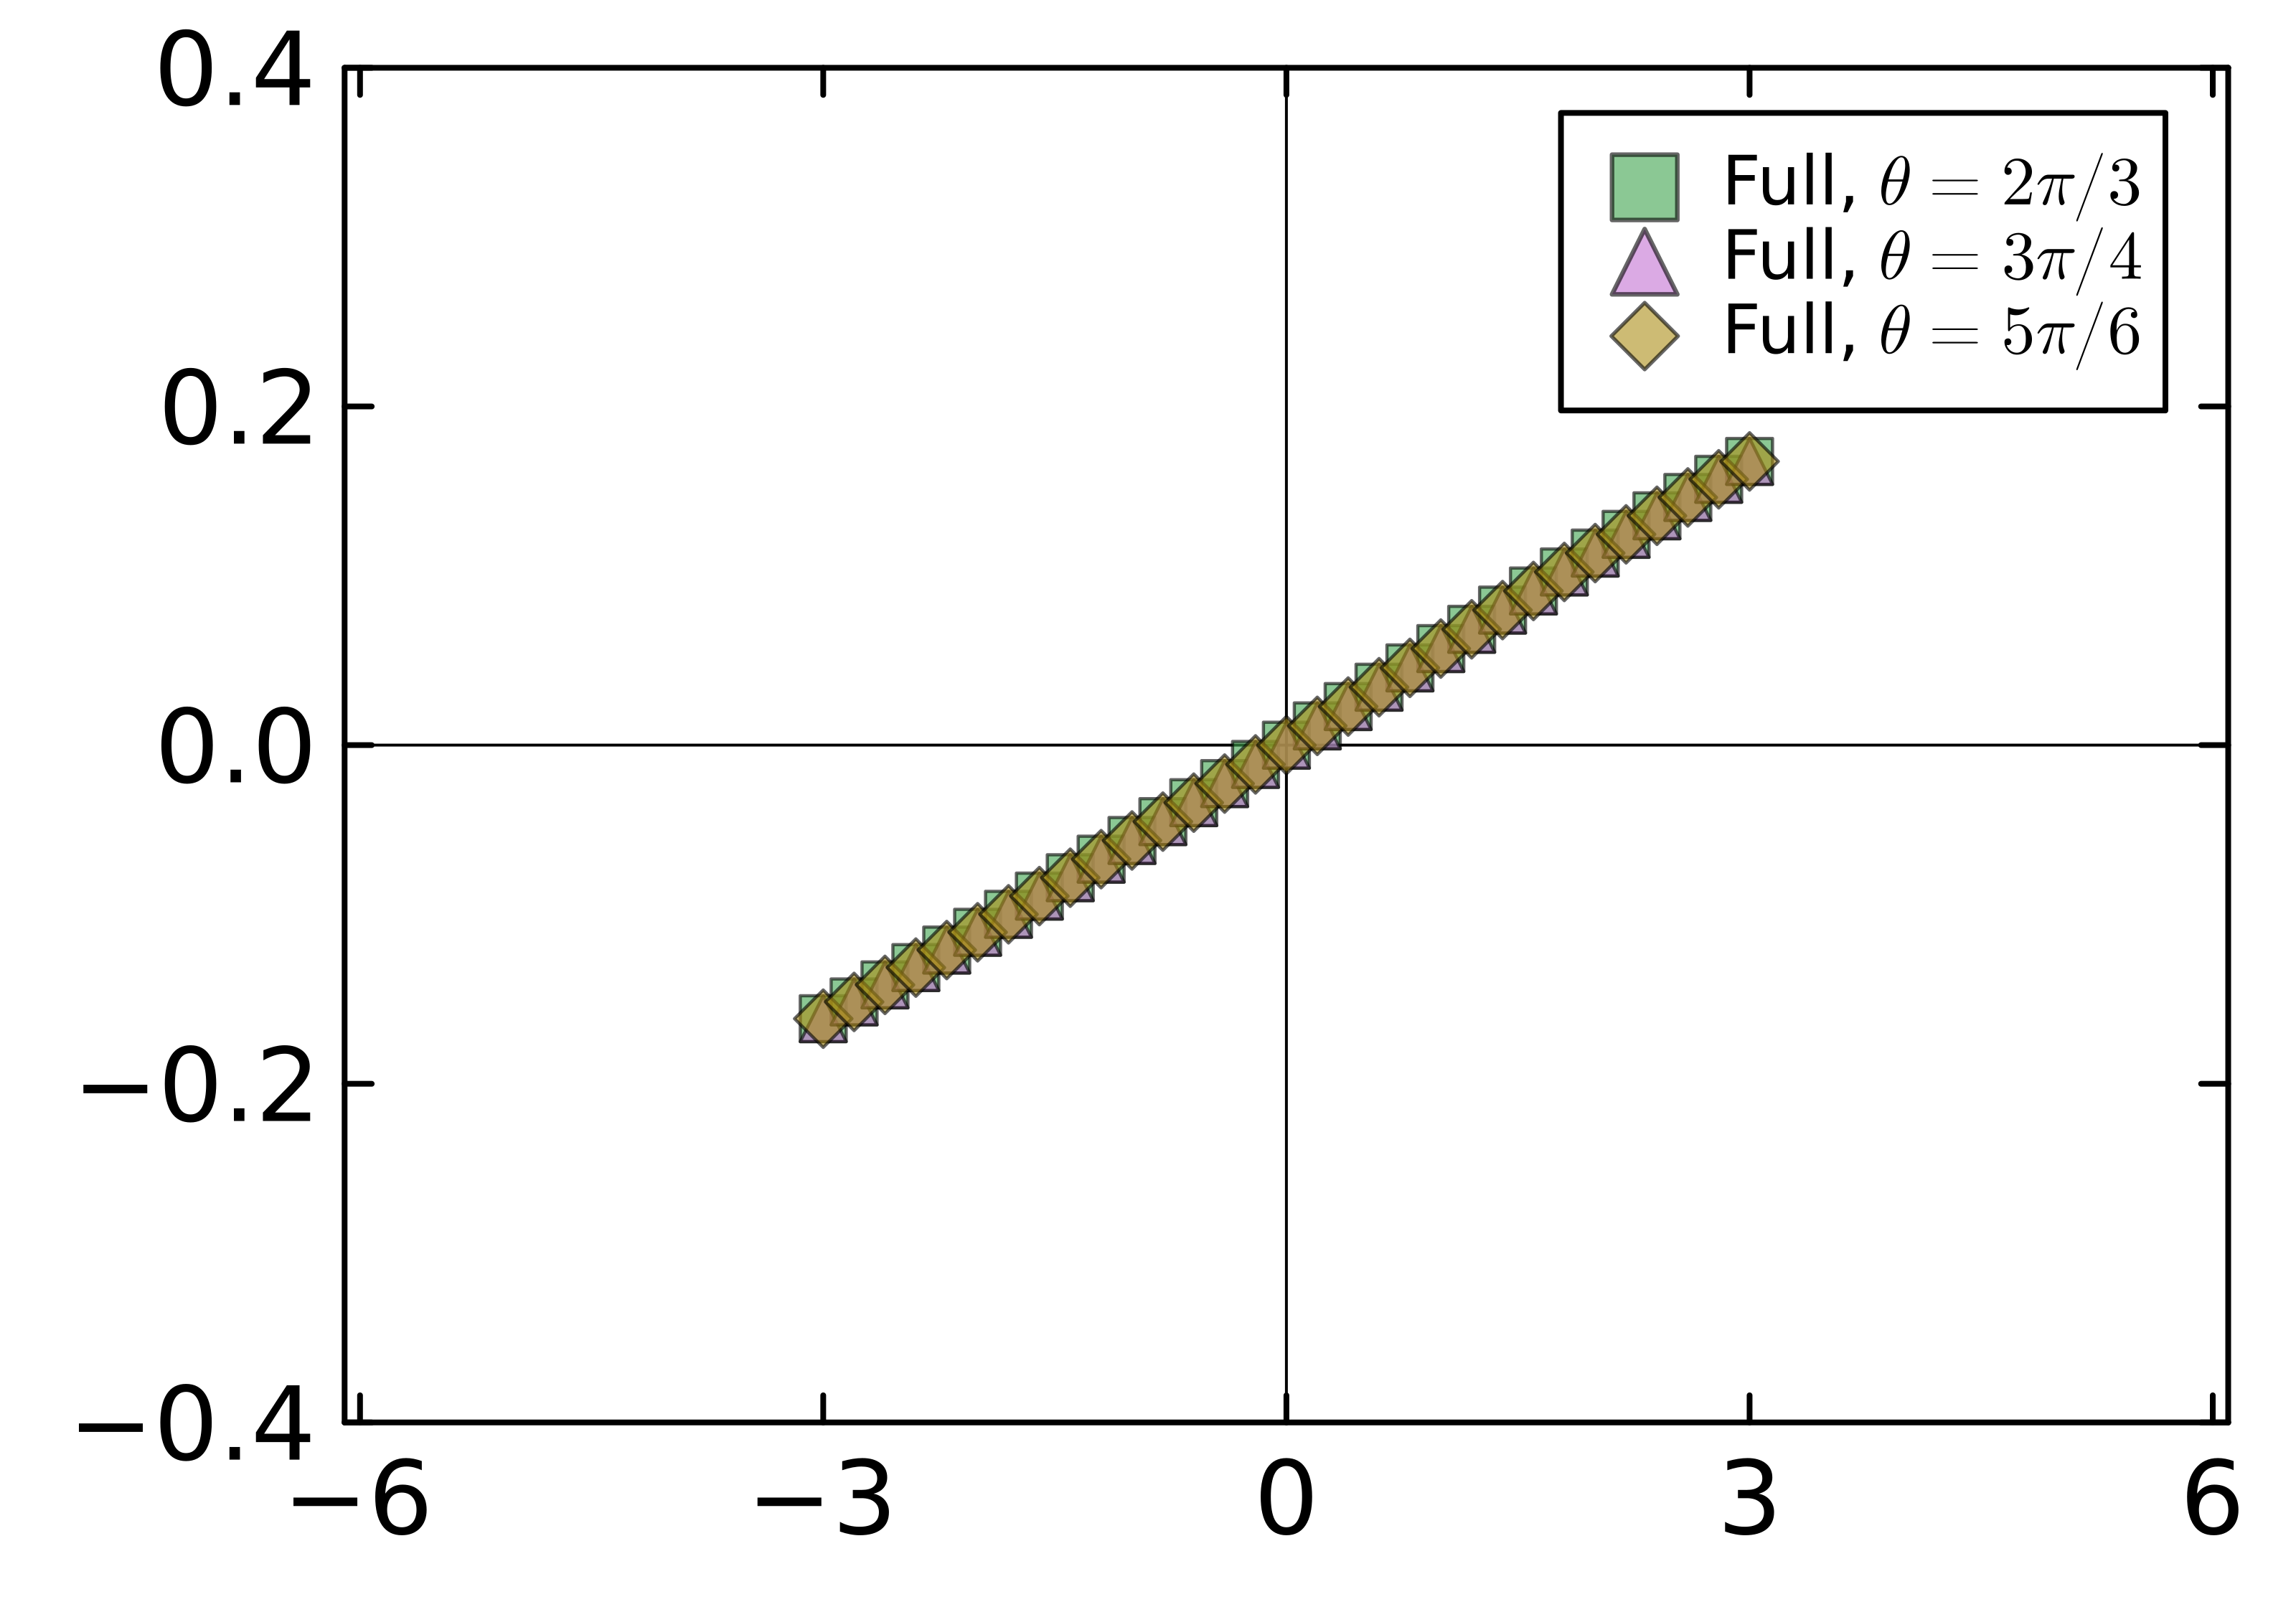

In [66]:
strainlist = collect(-3.0:0.2:3.0)

# Pre-allocate results (Thread-safe for writing if indices are unique)
blochlist = Vector{Vector{ComplexF64}}(undef, length(strainlist))

# Parallelize the outer loop
Threads.@threads for i in 1:length(strainlist)
	strain_val = strainlist[i]
	# --- Everything below is local to this specific thread/strain ---
	epsilonyy = -(sqrt((1 + strain_val / 100)^2 * 3 / 4 + 1 / 4) - 1) * 5
	println("Thread $(Threads.threadid()) doing strain $strain_val (Index $i)")
	flush(stdout)
	# 1. Initialize System
	# Note: 'lattice', 'Nsample', 'sz' must be defined in global scope
	graphene_sys = GrapheneBSE(lattice, [0.0, 0], Nsample; sz, epsilonyy)

	bloch_v, bloch_c1, bloch_c2 = graphene_sys.Bloch.valence, graphene_sys.Bloch.conduction1, graphene_sys.Bloch.conduction2
	bloch_states = [bloch_v]

	M_b1 = exciton.compute_M_matrix(bloch_states, (1, 0))
	M_b2 = exciton.compute_M_matrix(bloch_states, (0, 1))
	M_b3 = exciton.compute_M_matrix(bloch_states, (-1, -1))

	blist = [bi_1, bi_2, bi_3]
	M_blist = [M_b1, M_b2, M_b3]
	nbands = length(bloch_states)

	rlist = [
		sum(-wb / Nsample^2 * blist[bind] * angle(M_blist[bind][xi, yi, band, band])
			for xi ∈ 1:Nsample, yi ∈ 1:Nsample, bind ∈ 1:3)
		for band ∈ 1:nbands
	]

	# 2. First Descent (Valence)
	U0mn_mat = zeros(ComplexF64, Nsample, Nsample, nbands, nbands)
	for xi ∈ 1:Nsample, yi ∈ 1:Nsample, nband_ind ∈ 1:nbands
		U0mn_mat[xi, yi, nband_ind, nband_ind] = 1
	end

	updated_Umn_mat = exciton.one_descent_step_singleband(U0mn_mat; M0_blist = M_blist, wb, varied_step = false, Nsample, blist, rlist, verbose = false)
	for steps ∈ 1:200
		updated_Umn_mat = exciton.one_descent_step_singleband(updated_Umn_mat; M0_blist = M_blist, wb, varied_step = false, alphaval = 0.1, Nsample, blist, rlist, verbose = false)
	end

	oldv = graphene_sys.Bloch.valence
	newv = 0 * oldv
	for xi ∈ 1:Nsample, yi ∈ 1:Nsample
		newv[xi, yi, :] = updated_Umn_mat[xi, yi, 1, 1] * oldv[xi, yi, :]
	end

	# 3. Second Descent (Conduction)
	bloch_states = [bloch_c1, bloch_c2]
	M_b1 = exciton.compute_M_matrix(bloch_states, (1, 0))
	M_b2 = exciton.compute_M_matrix(bloch_states, (0, 1))
	M_b3 = exciton.compute_M_matrix(bloch_states, (-1, -1))

	M_blist = [M_b1, M_b2, M_b3]
	nbands = length(bloch_states)

	rlist = [
		sum(-wb / Nsample^2 * blist[bind] * angle(M_blist[bind][xi, yi, band, band])
			for xi ∈ 1:Nsample, yi ∈ 1:Nsample, bind ∈ 1:3)
		for band ∈ 1:nbands
	]

	U0mn_mat = zeros(ComplexF64, Nsample, Nsample, nbands, nbands)
	for xi ∈ 1:Nsample, yi ∈ 1:Nsample, nband_ind ∈ 1:nbands
		U0mn_mat[xi, yi, nband_ind, nband_ind] = 1
	end

	updated_Umn_mat = exciton.one_descent_step(U0mn_mat; M0_blist = M_blist, wb, nbands, Nsample, blist, rlist, verbose = false)
	for steps ∈ 1:200
		updated_Umn_mat = exciton.one_descent_step(updated_Umn_mat; M0_blist = M_blist, wb, nbands, Nsample, blist, rlist, verbose = false)
	end

	oldc1 = graphene_sys.Bloch.conduction1
	oldc2 = graphene_sys.Bloch.conduction2
	newc1 = 0 * oldc1
	newc2 = 0 * oldc2

	for xi ∈ 1:Nsample, yi ∈ 1:Nsample
		newc1[xi, yi, :] = updated_Umn_mat[xi, yi, 1, 1] * oldc1[xi, yi, :] + updated_Umn_mat[xi, yi, 2, 1] * oldc2[xi, yi, :]
		newc2[xi, yi, :] = updated_Umn_mat[xi, yi, 1, 2] * oldc1[xi, yi, :] + updated_Umn_mat[xi, yi, 2, 2] * oldc2[xi, yi, :]
	end

	oldecv = graphene_sys.Bloch.ecvmat
	newecv = 0 * oldecv
	for xi ∈ 1:Nsample, yi ∈ 1:Nsample
		urotated = updated_Umn_mat[xi, yi, :, :]
		newecv[xi, yi, :, :] = urotated' * oldecv[xi, yi, :, :] * urotated
	end

	# 4. Construct MLWF System and Solve BSE
	mlwf_bloch = BlochStates(newv, newc1, newc2, newecv)

	# NOTE: We shadow the variable 'graphene_sys' locally so it doesn't conflict
	local_sys = GrapheneBSE(graphene_sys.lattice, graphene_sys.kappa, graphene_sys.Nsample, mlwf_bloch, nothing, nothing)
	local_sys = add_bse_kernel(local_sys, VInt)
	local_sys = add_wannier(local_sys)

	wv, wc1, wc2 = local_sys.Wannier.valence, local_sys.Wannier.conduction1, local_sys.Wannier.conduction2

	blochlist[i] = exciton_subroutine_4th(wv, wc1, wc2; state = 1, polarization = [[cos(2pi / 3), sin(2pi / 3)], [cos(3pi / 4), sin(3pi / 4)], [cos(5pi / 6), sin(5pi / 6)]], VInt, lattice, epsilonyy, sz = 1, Nsample)
end

polarization_list=Vector{Float64}(undef, length(strainlist))
for i ∈ 1:length(strainlist)
	polarization_list[i]=real(blochlist[i][1])
end

polarization_list2=Vector{Float64}(undef, length(strainlist))
for i ∈ 1:length(strainlist)
	polarization_list2[i]=real(blochlist[i][2])
end

polarization_list3=Vector{Float64}(undef, length(strainlist))
for i ∈ 1:length(strainlist)
	polarization_list3[i]=real(blochlist[i][3])
end


hline([0], color = :black, lw = 0.5, label = false, xlim = (-6.1, 6.1), ylim = (-0.4, 0.4), xticks = ([-6, -3, 0, 3, 6]))

# Vertical axis at x = 0
vline!([0], color = :black, lw = 0.5, label = false)
scatter!(
	strainlist,
	[polarization_list, polarization_list2, polarization_list3] .* 100,
	framestyle = :box,
	xgrid = false,
	ygrid = false,
	label = [ "Full, "*L"\theta=2\pi/3" "Full, "*L" \theta=3\pi/4" "Full, "*L" \theta=5\pi/6"],
	tickfontsize = 12,
	dpi = 800,
	size = (400, 280),
	markershape = [:square :utriangle :diamond],
	ms = [4 4 5],
	markeralpha = 0.6,
)


In [126]:
hline([0], color = :black, lw = 0.5, label = false, xlim = (-3.1, 3.1), ylim = (-0.21, 0.21),yticks=([-0.2,-0.1,0,0.1,0.2]), xticks = ([-3,-2, -1, 0, 1, 2,3]))

# Vertical axis at x = 0
vline!([0], color = :black, lw = 0.5, label = false)
scatter!(
	strainlist,
	[polarization_list, polarization_list2] .* 100,
	framestyle = :box,
	xgrid = false,
	ygrid = false,
	label = [ "Full, "*L"\theta=2\pi/3" "Full, "*L" \theta=3\pi/4"],
	tickfontsize = 10,
	dpi = 800,
	size = (420, 320),
	markershape = [:square :diamond],
	ms = [4 4.5 ],
	markeralpha = 0.6,
)
plot!(collect(-3:0.06:3),shifty_3b*100,label = "Wannier",lw=1.5,color=:black)
savefig("fig3d.png")

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3d.png"

# Fig 3d inset

In [80]:
strain_val=2.66
epsilonyy = -(sqrt((1 + strain_val / 100)^2 * 3 / 4 + 1 / 4) - 1) * 5

-0.10007517101463859

In [91]:
kx = 4pi / 3
ky = 0
θlist = 0:0.1:pi

# Preallocate result array
rshift1 = zeros(Float64,length(θlist))
strain_val=0

Threads.@threads for i in 1:length(θlist)
    strain_val=0
	epsilonyy = -(sqrt((1 + strain_val / 100)^2 * 3 / 4 + 1 / 4) - 1) * 5
	println("Thread $(Threads.threadid()) doing strain $strain_val (Index $i)")
	flush(stdout)
	# 1. Initialize System
	# Note: 'lattice', 'Nsample', 'sz' must be defined in global scope
	graphene_sys = GrapheneBSE(lattice, [0.0, 0], Nsample; sz, epsilonyy)

	bloch_v, bloch_c1, bloch_c2 = graphene_sys.Bloch.valence, graphene_sys.Bloch.conduction1, graphene_sys.Bloch.conduction2
	bloch_states = [bloch_v]

	M_b1 = exciton.compute_M_matrix(bloch_states, (1, 0))
	M_b2 = exciton.compute_M_matrix(bloch_states, (0, 1))
	M_b3 = exciton.compute_M_matrix(bloch_states, (-1, -1))

	blist = [bi_1, bi_2, bi_3]
	M_blist = [M_b1, M_b2, M_b3]
	nbands = length(bloch_states)

	rlist = [
		sum(-wb / Nsample^2 * blist[bind] * angle(M_blist[bind][xi, yi, band, band])
			for xi ∈ 1:Nsample, yi ∈ 1:Nsample, bind ∈ 1:3)
		for band ∈ 1:nbands
	]

	# 2. First Descent (Valence)
	U0mn_mat = zeros(ComplexF64, Nsample, Nsample, nbands, nbands)
	for xi ∈ 1:Nsample, yi ∈ 1:Nsample, nband_ind ∈ 1:nbands
		U0mn_mat[xi, yi, nband_ind, nband_ind] = 1
	end

	updated_Umn_mat = exciton.one_descent_step_singleband(U0mn_mat; M0_blist = M_blist, wb, varied_step = false, Nsample, blist, rlist, verbose = false)
	for steps ∈ 1:200
		updated_Umn_mat = exciton.one_descent_step_singleband(updated_Umn_mat; M0_blist = M_blist, wb, varied_step = false, alphaval = 0.1, Nsample, blist, rlist, verbose = false)
	end

	oldv = graphene_sys.Bloch.valence
	newv = 0 * oldv
	for xi ∈ 1:Nsample, yi ∈ 1:Nsample
		newv[xi, yi, :] = updated_Umn_mat[xi, yi, 1, 1] * oldv[xi, yi, :]
	end

	# 3. Second Descent (Conduction)
	bloch_states = [bloch_c1, bloch_c2]
	M_b1 = exciton.compute_M_matrix(bloch_states, (1, 0))
	M_b2 = exciton.compute_M_matrix(bloch_states, (0, 1))
	M_b3 = exciton.compute_M_matrix(bloch_states, (-1, -1))

	M_blist = [M_b1, M_b2, M_b3]
	nbands = length(bloch_states)

	rlist = [
		sum(-wb / Nsample^2 * blist[bind] * angle(M_blist[bind][xi, yi, band, band])
			for xi ∈ 1:Nsample, yi ∈ 1:Nsample, bind ∈ 1:3)
		for band ∈ 1:nbands
	]

	U0mn_mat = zeros(ComplexF64, Nsample, Nsample, nbands, nbands)
	for xi ∈ 1:Nsample, yi ∈ 1:Nsample, nband_ind ∈ 1:nbands
		U0mn_mat[xi, yi, nband_ind, nband_ind] = 1
	end

	updated_Umn_mat = exciton.one_descent_step(U0mn_mat; M0_blist = M_blist, wb, nbands, Nsample, blist, rlist, verbose = false)
	for steps ∈ 1:200
		updated_Umn_mat = exciton.one_descent_step(updated_Umn_mat; M0_blist = M_blist, wb, nbands, Nsample, blist, rlist, verbose = false)
	end

	oldc1 = graphene_sys.Bloch.conduction1
	oldc2 = graphene_sys.Bloch.conduction2
	newc1 = 0 * oldc1
	newc2 = 0 * oldc2

	for xi ∈ 1:Nsample, yi ∈ 1:Nsample
		newc1[xi, yi, :] = updated_Umn_mat[xi, yi, 1, 1] * oldc1[xi, yi, :] + updated_Umn_mat[xi, yi, 2, 1] * oldc2[xi, yi, :]
		newc2[xi, yi, :] = updated_Umn_mat[xi, yi, 1, 2] * oldc1[xi, yi, :] + updated_Umn_mat[xi, yi, 2, 2] * oldc2[xi, yi, :]
	end

	oldecv = graphene_sys.Bloch.ecvmat
	newecv = 0 * oldecv
	for xi ∈ 1:Nsample, yi ∈ 1:Nsample
		urotated = updated_Umn_mat[xi, yi, :, :]
		newecv[xi, yi, :, :] = urotated' * oldecv[xi, yi, :, :] * urotated
	end

	# 4. Construct MLWF System and Solve BSE
	mlwf_bloch = BlochStates(newv, newc1, newc2, newecv)

	# NOTE: We shadow the variable 'graphene_sys' locally so it doesn't conflict
	local_sys = GrapheneBSE(graphene_sys.lattice, graphene_sys.kappa, graphene_sys.Nsample, mlwf_bloch, nothing, nothing)
	local_sys = add_bse_kernel(local_sys, VInt)
	local_sys = add_wannier(local_sys)

	wv, wc1, wc2 = local_sys.Wannier.valence, local_sys.Wannier.conduction1, local_sys.Wannier.conduction2

	rshift1[i] = real.(exciton_subroutine_4th(wv, wc1, wc2; state = 1, polarization = [[cos(θlist[i]), sin(θlist[i])]], VInt, lattice, epsilonyy, sz = 1, Nsample)[1])
end

blochlist_3d_inset=copy(rshift1)
θlist_3d_inset=copy(θlist);

Thread 3 doing strain 0 (Index 17)
Thread 4 doing strain 0 (Index 25)Thread 2 doing strain 0 (Index 9)
Thread 1 doing strain 0 (Index 1)

gauge fixing successful!
gauge fixing successful!
gauge fixing successful!
gauge fixing successful!
Center Energy: 1.264824750558688
Center Energy: 1.2648247505586863
Center Energy: 1.264824750558688
Center Energy: 1.2648247505586858
rtot for all polarizations: ComplexF64[-3.1511341520842063e-7 + 2.0483857365028502e-8im]
Thread 1 doing strain 0 (Index 18)
gauge fixing successful!
rtot for all polarizations: ComplexF64[-3.0208825143384904e-7 + 2.0484800197666438e-8im]
Thread 1 doing strain 0 (Index 10)
gauge fixing successful!
rtot for all polarizations: ComplexF64[-2.887528845836101e-7 + 2.0484839826400008e-8im]
Thread 3 doing strain 0 (Index 2)
rtot for all polarizations: ComplexF64[-3.01017763848606e-7 + 2.048460085262207e-8im]
Thread 4 doing strain 0 (Index 26)
gauge fixing successful!
gauge fixing successful!
Center Energy: 1.2648247505586885
rto

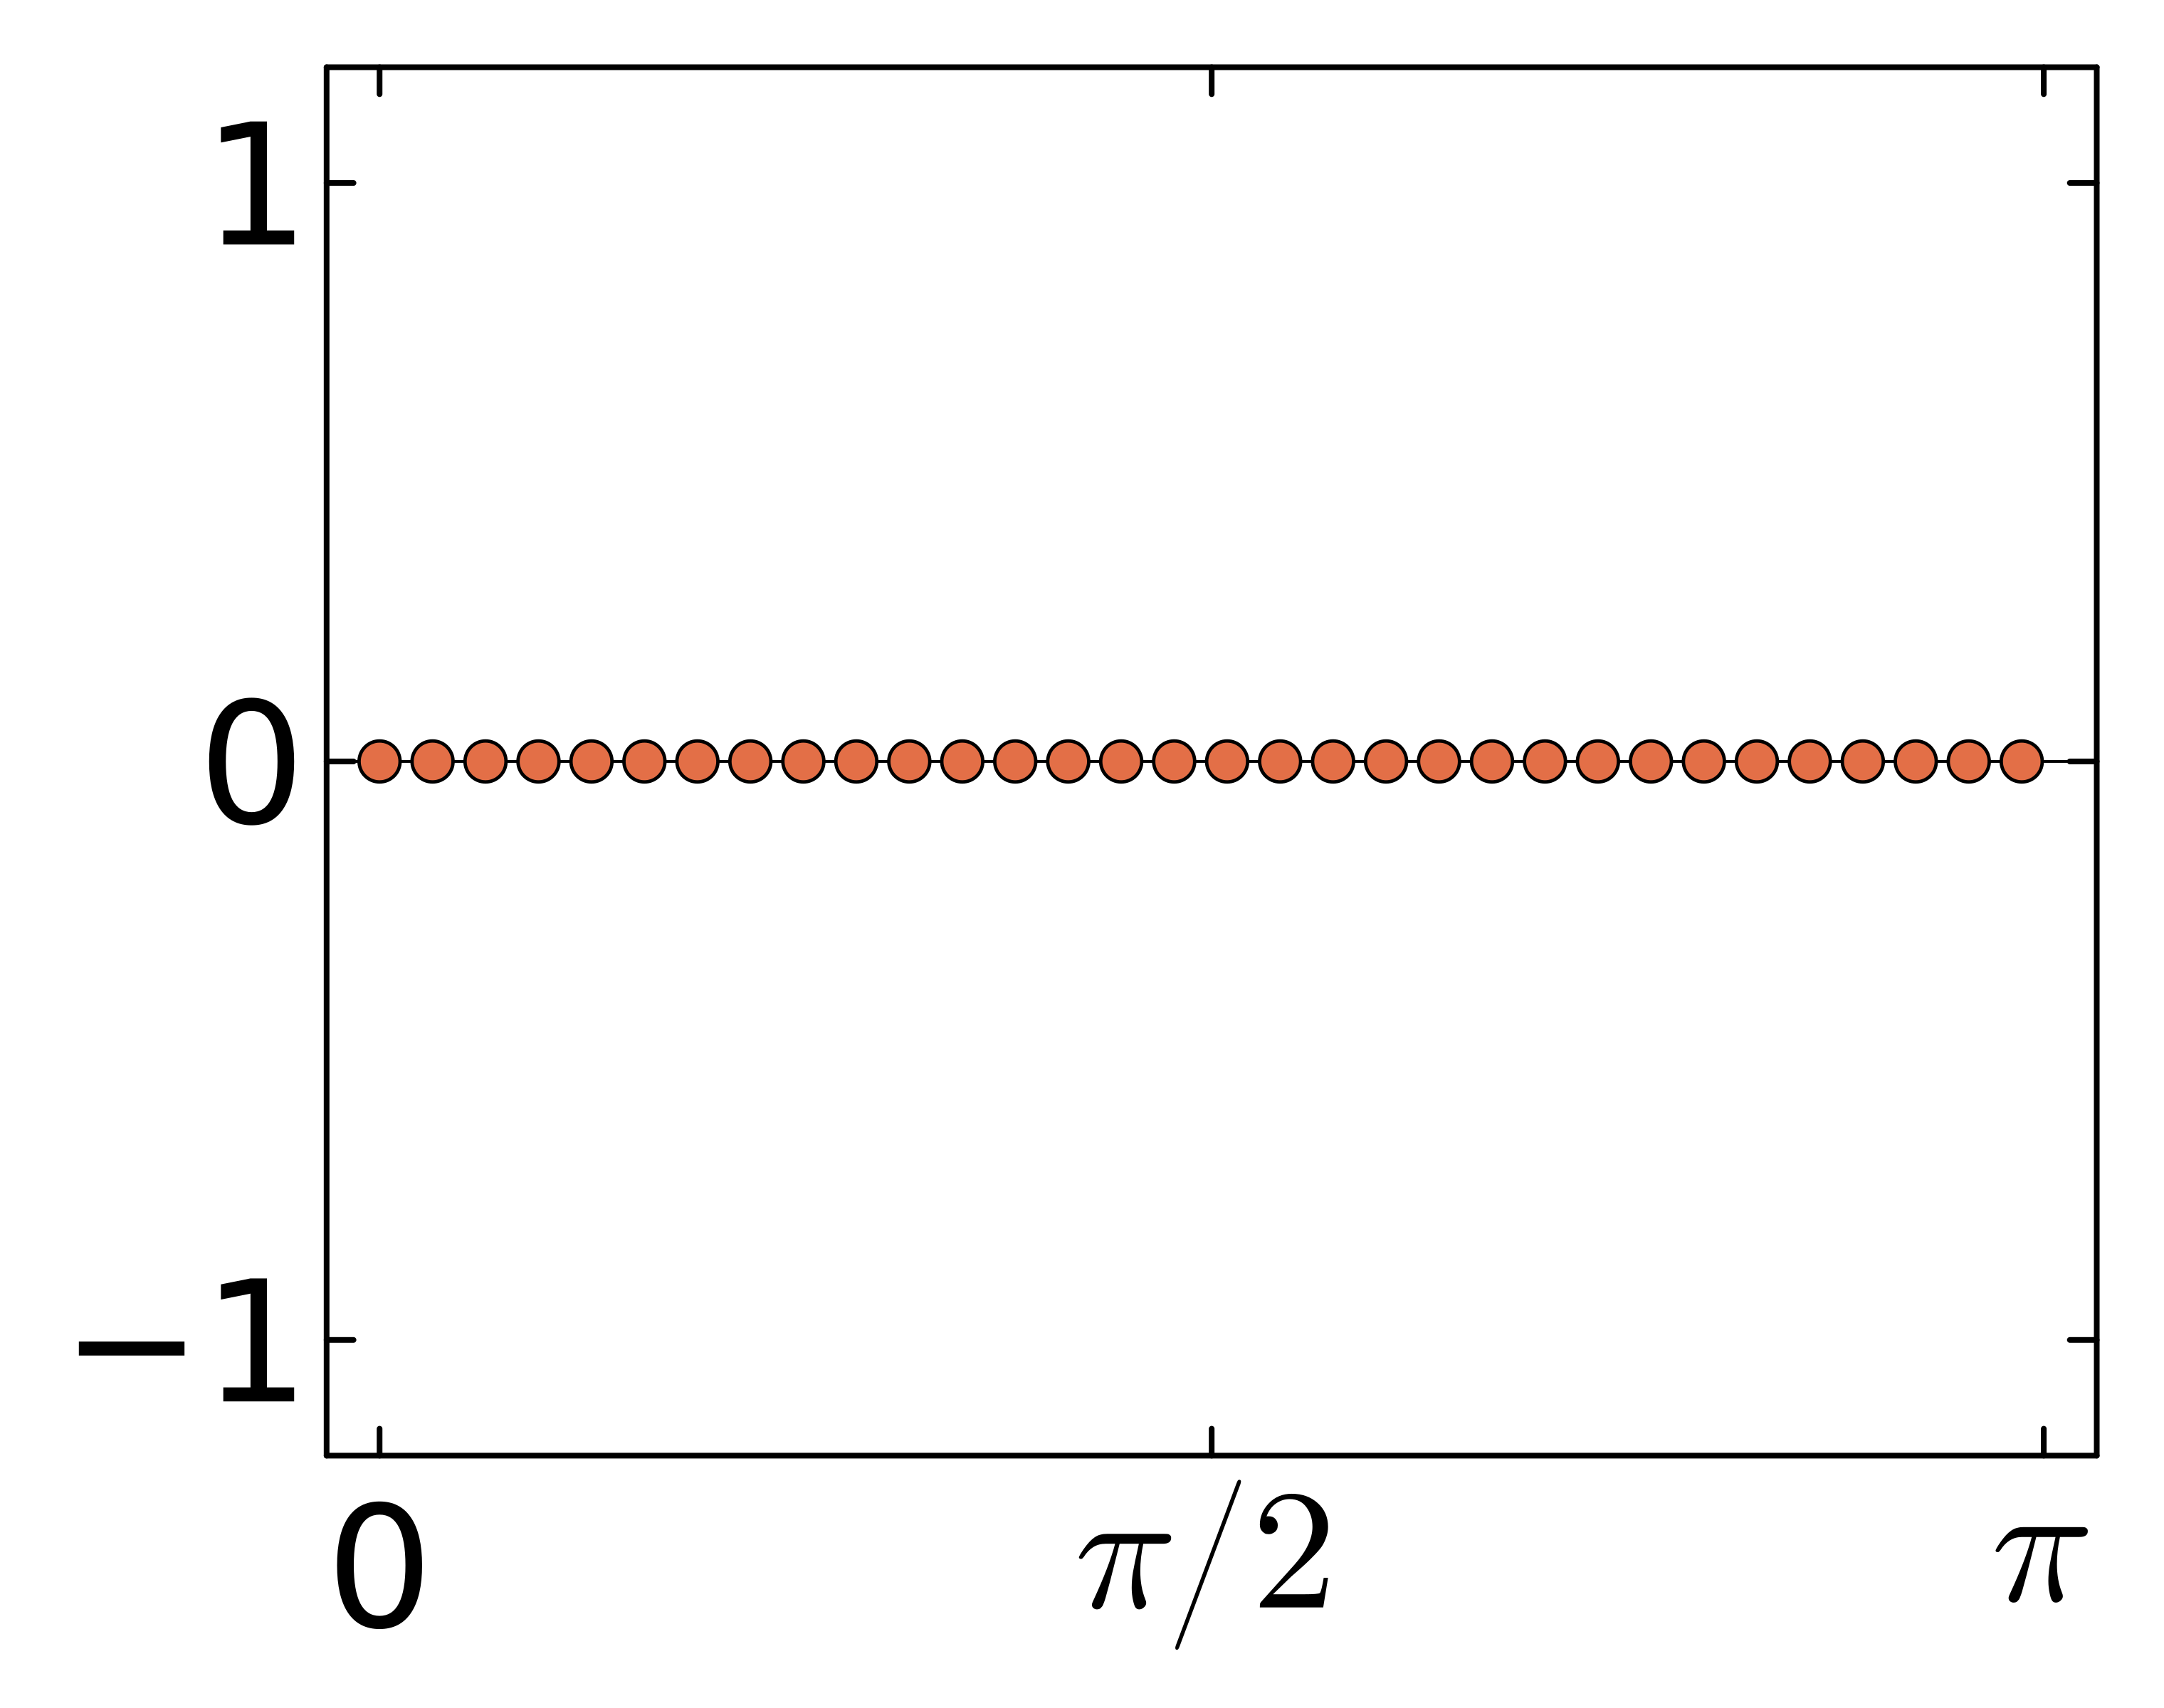

In [92]:
hline([0], color=:black, lw=0.5, label=false, xlim=(-0.1, pi+0.1), xticks=([0, pi/2,pi],["0", L"\pi/2", L"\pi"]))

scatter!(θlist_3d_inset, real.(blochlist_3d_inset) .* 100, framestyle=:box, xgrid=false, ylim=(-1.2, 1.2), legendfontsize=17, yticks=([-1, 0, 1]), ygrid=false, label=false, tickfontsize=20, dpi=800, size=(380, 300))


In [ ]:
strain_val=5.299576
epsilonyy = -(sqrt((1 + strain_val / 100)^2 * 3 / 4 + 1 / 4) - 1) * 5

-0.20000012724394778

In [190]:
strain_val=2.65805
epsilonyy = -(sqrt((1 + strain_val / 100)^2 * 3 / 4 + 1 / 4) - 1) * 5

-0.10000157410560817

In [191]:
kx = 4pi / 3
ky = 0
θlist = 0:0.1:pi

# Preallocate result array
rshift2 = zeros(Float64,length(θlist))

Threads.@threads for i in 1:length(θlist)
    strain_val=2.65805
	epsilonyy = -(sqrt((1 + strain_val / 100)^2 * 3 / 4 + 1 / 4) - 1) * 5
	println("Thread $(Threads.threadid()) doing strain $strain_val (Index $i)")
	flush(stdout)
	# 1. Initialize System
	# Note: 'lattice', 'Nsample', 'sz' must be defined in global scope
	graphene_sys = GrapheneBSE(lattice, [0.0, 0], Nsample; sz, epsilonyy)

	bloch_v, bloch_c1, bloch_c2 = graphene_sys.Bloch.valence, graphene_sys.Bloch.conduction1, graphene_sys.Bloch.conduction2
	bloch_states = [bloch_v]

	M_b1 = exciton.compute_M_matrix(bloch_states, (1, 0))
	M_b2 = exciton.compute_M_matrix(bloch_states, (0, 1))
	M_b3 = exciton.compute_M_matrix(bloch_states, (-1, -1))

	blist = [bi_1, bi_2, bi_3]
	M_blist = [M_b1, M_b2, M_b3]
	nbands = length(bloch_states)

	rlist = [
		sum(-wb / Nsample^2 * blist[bind] * angle(M_blist[bind][xi, yi, band, band])
			for xi ∈ 1:Nsample, yi ∈ 1:Nsample, bind ∈ 1:3)
		for band ∈ 1:nbands
	]

	# 2. First Descent (Valence)
	U0mn_mat = zeros(ComplexF64, Nsample, Nsample, nbands, nbands)
	for xi ∈ 1:Nsample, yi ∈ 1:Nsample, nband_ind ∈ 1:nbands
		U0mn_mat[xi, yi, nband_ind, nband_ind] = 1
	end

	updated_Umn_mat = exciton.one_descent_step_singleband(U0mn_mat; M0_blist = M_blist, wb, varied_step = false, Nsample, blist, rlist, verbose = false)
	for steps ∈ 1:200
		updated_Umn_mat = exciton.one_descent_step_singleband(updated_Umn_mat; M0_blist = M_blist, wb, varied_step = false, alphaval = 0.1, Nsample, blist, rlist, verbose = false)
	end

	oldv = graphene_sys.Bloch.valence
	newv = 0 * oldv
	for xi ∈ 1:Nsample, yi ∈ 1:Nsample
		newv[xi, yi, :] = updated_Umn_mat[xi, yi, 1, 1] * oldv[xi, yi, :]
	end

	# 3. Second Descent (Conduction)
	bloch_states = [bloch_c1, bloch_c2]
	M_b1 = exciton.compute_M_matrix(bloch_states, (1, 0))
	M_b2 = exciton.compute_M_matrix(bloch_states, (0, 1))
	M_b3 = exciton.compute_M_matrix(bloch_states, (-1, -1))

	M_blist = [M_b1, M_b2, M_b3]
	nbands = length(bloch_states)

	rlist = [
		sum(-wb / Nsample^2 * blist[bind] * angle(M_blist[bind][xi, yi, band, band])
			for xi ∈ 1:Nsample, yi ∈ 1:Nsample, bind ∈ 1:3)
		for band ∈ 1:nbands
	]

	U0mn_mat = zeros(ComplexF64, Nsample, Nsample, nbands, nbands)
	for xi ∈ 1:Nsample, yi ∈ 1:Nsample, nband_ind ∈ 1:nbands
		U0mn_mat[xi, yi, nband_ind, nband_ind] = 1
	end

	updated_Umn_mat = exciton.one_descent_step(U0mn_mat; M0_blist = M_blist, wb, nbands, Nsample, blist, rlist, verbose = false)
	for steps ∈ 1:200
		updated_Umn_mat = exciton.one_descent_step(updated_Umn_mat; M0_blist = M_blist, wb, nbands, Nsample, blist, rlist, verbose = false)
	end

	oldc1 = graphene_sys.Bloch.conduction1
	oldc2 = graphene_sys.Bloch.conduction2
	newc1 = 0 * oldc1
	newc2 = 0 * oldc2

	for xi ∈ 1:Nsample, yi ∈ 1:Nsample
		newc1[xi, yi, :] = updated_Umn_mat[xi, yi, 1, 1] * oldc1[xi, yi, :] + updated_Umn_mat[xi, yi, 2, 1] * oldc2[xi, yi, :]
		newc2[xi, yi, :] = updated_Umn_mat[xi, yi, 1, 2] * oldc1[xi, yi, :] + updated_Umn_mat[xi, yi, 2, 2] * oldc2[xi, yi, :]
	end

	oldecv = graphene_sys.Bloch.ecvmat
	newecv = 0 * oldecv
	for xi ∈ 1:Nsample, yi ∈ 1:Nsample
		urotated = updated_Umn_mat[xi, yi, :, :]
		newecv[xi, yi, :, :] = urotated' * oldecv[xi, yi, :, :] * urotated
	end

	# 4. Construct MLWF System and Solve BSE
	mlwf_bloch = BlochStates(newv, newc1, newc2, newecv)

	# NOTE: We shadow the variable 'graphene_sys' locally so it doesn't conflict
	local_sys = GrapheneBSE(graphene_sys.lattice, graphene_sys.kappa, graphene_sys.Nsample, mlwf_bloch, nothing, nothing)
	local_sys = add_bse_kernel(local_sys, VInt)
	local_sys = add_wannier(local_sys)

	wv, wc1, wc2 = local_sys.Wannier.valence, local_sys.Wannier.conduction1, local_sys.Wannier.conduction2

	rshift2[i] = real.(exciton_subroutine_4th(wv, wc1, wc2; state = 1, polarization = [[cos(θlist[i]), sin(θlist[i])]], VInt, lattice, epsilonyy, sz = 1, Nsample)[1])
end

blochlist_3d_inset_2=copy(rshift2)
θlist_3d_inset_2=copy(θlist);

Thread 1 doing strain 2.65805 (Index 25)
Thread 4 doing strain 2.65805 (Index 17)Thread 3 doing strain 2.65805 (Index 9)
Thread 2 doing strain 2.65805 (Index 1)

gauge fixing successful!
gauge fixing successful!
gauge fixing successful!
gauge fixing successful!
Center Energy: 1.0812785682703416
Center Energy: 1.0812785682703394
Center Energy: 1.0812785682703399
Center Energy: 1.081278568270342
rtot for all polarizations: ComplexF64[0.0014939356540343968 + 2.0860679739750266e-8im]
Thread 1 doing strain 2.65805 (Index 18)
gauge fixing successful!
rtot for all polarizations: ComplexF64[0.001493953747057994 + 2.0860239384433248e-8im]
Thread 1 doing strain 2.65805 (Index 2)
gauge fixing successful!
rtot for all polarizations: ComplexF64[0.0014939455860185618 + 2.0860770043369308e-8im]
Thread 3 doing strain 2.65805 (Index 26)
gauge fixing successful!
rtot for all polarizations: ComplexF64[0.0014939449329180593 + 2.0859397468548917e-8im]
Thread 4 doing strain 2.65805 (Index 10)
gauge fixing s

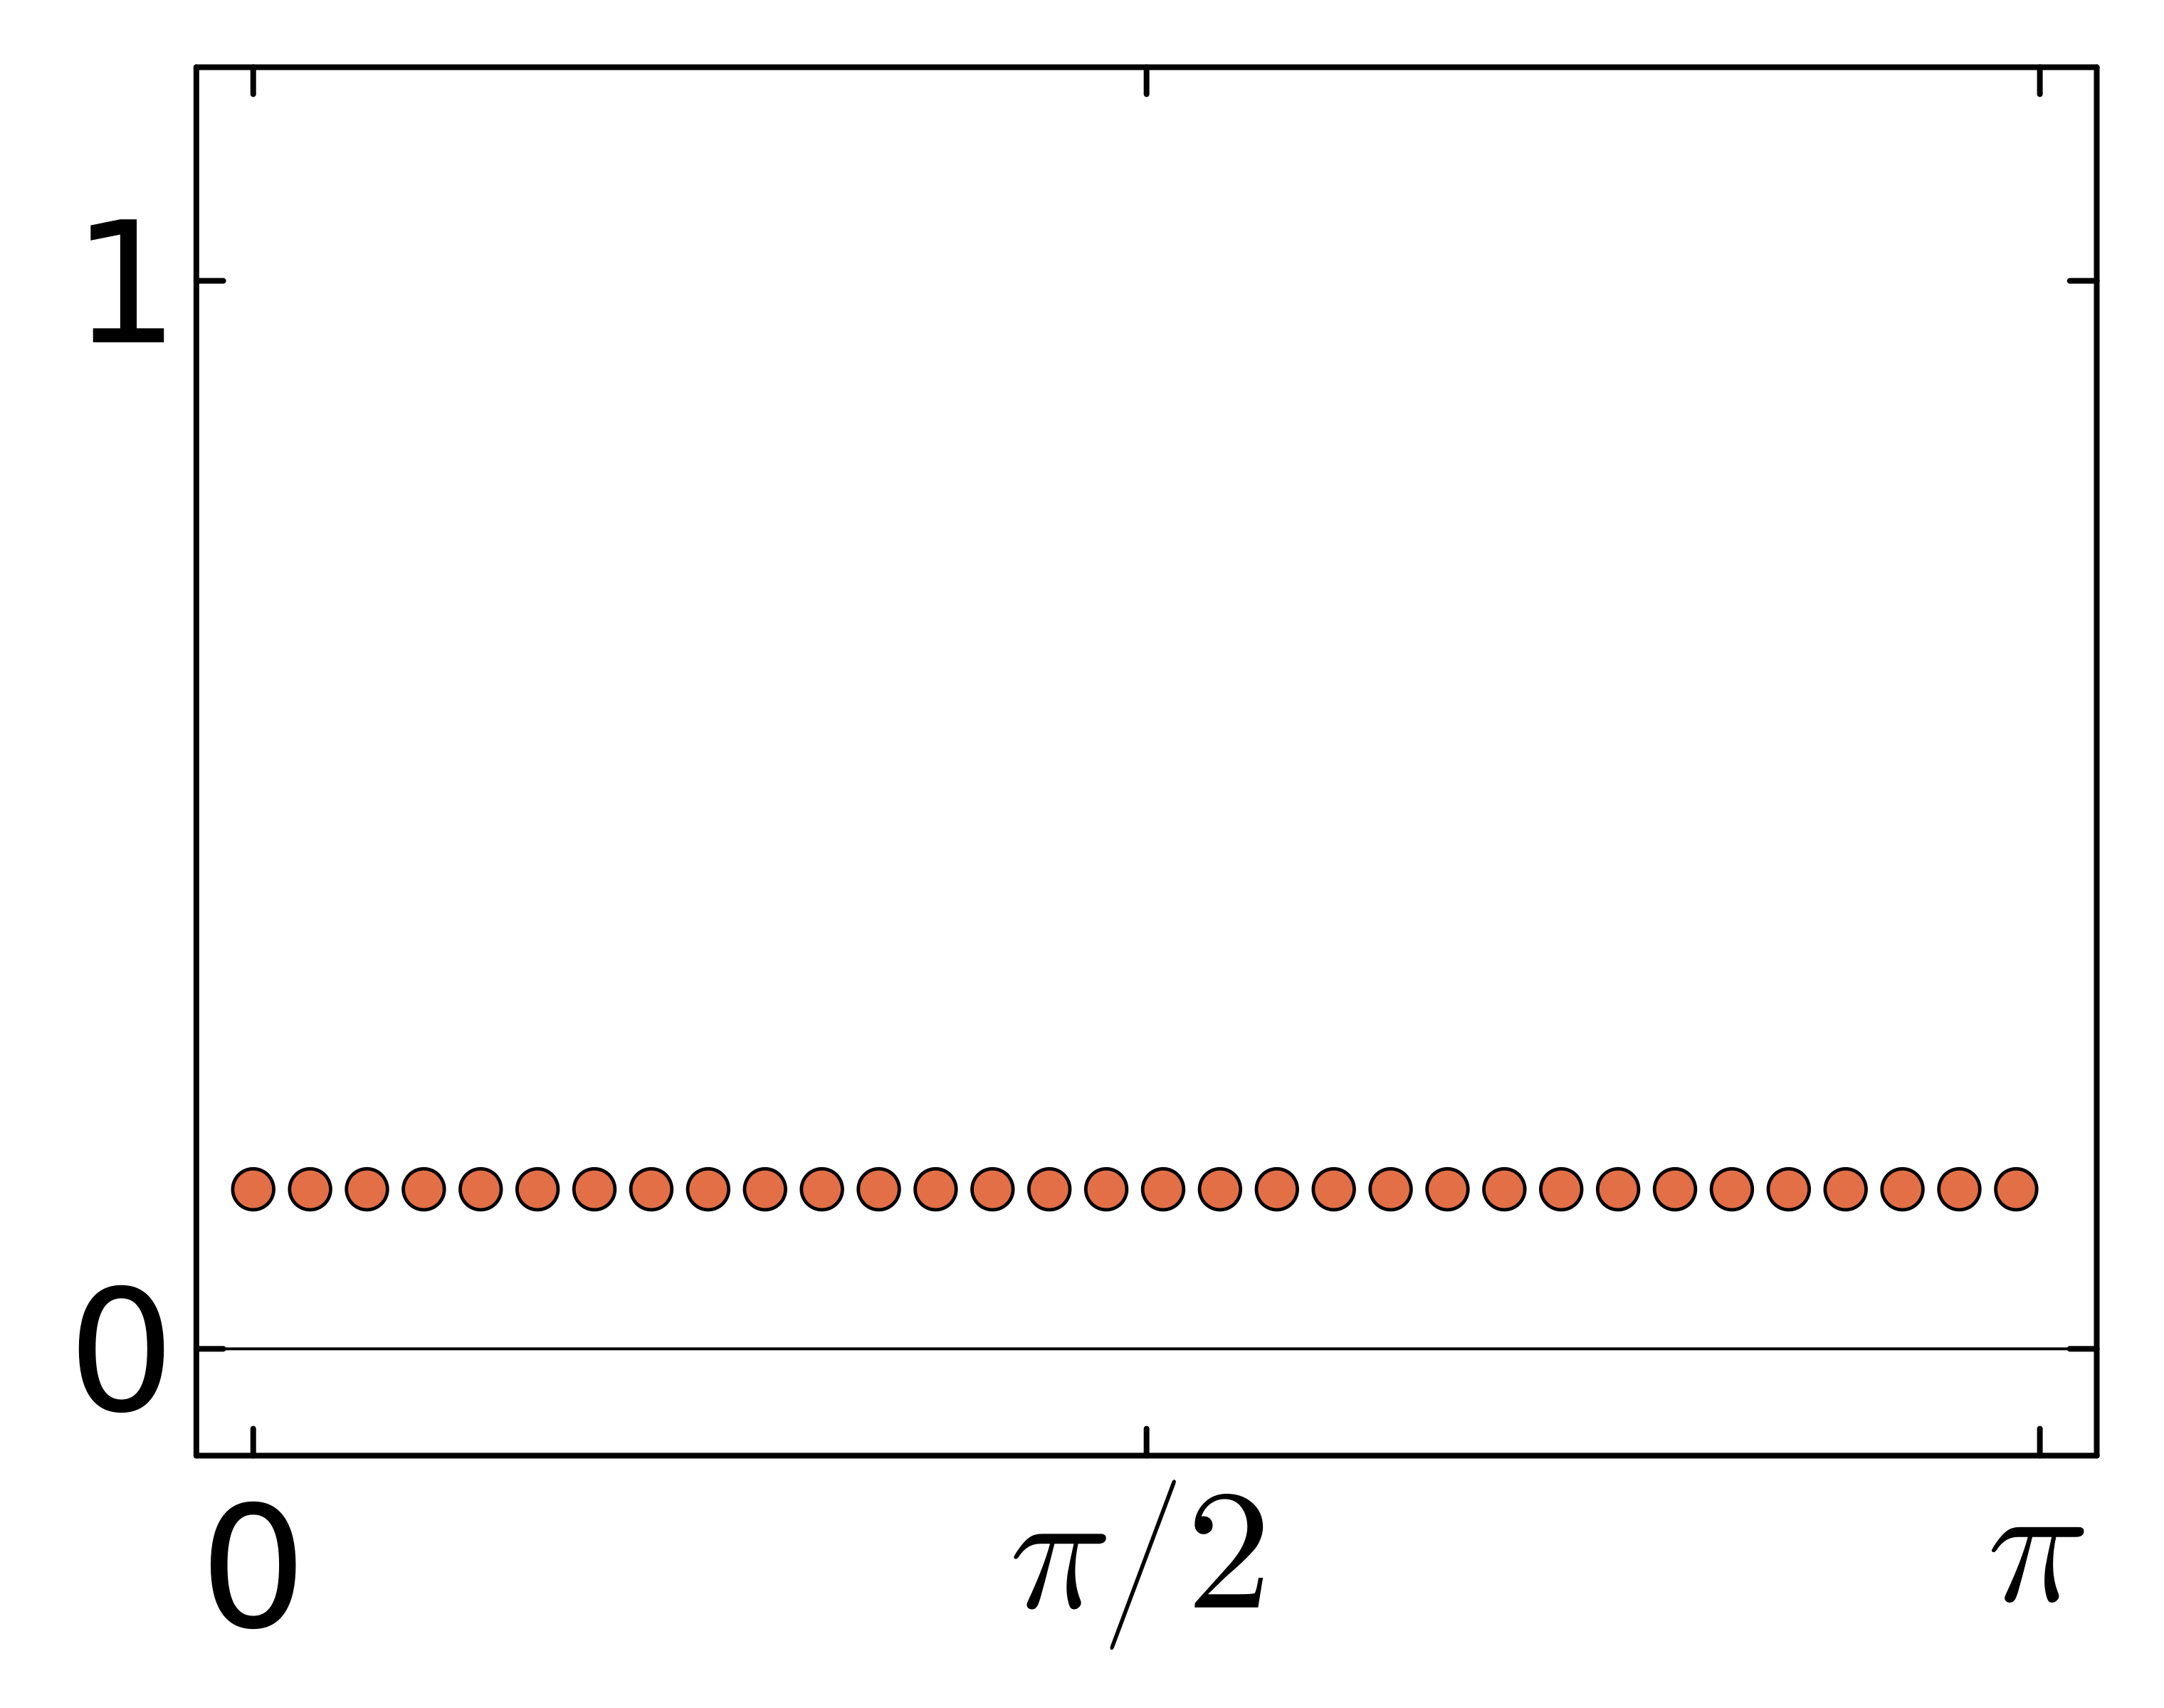

In [192]:
hline([0], color=:black, lw=0.5, label=false, xlim=(-0.1, pi+0.1), xticks=([0, pi/2,pi],["0", L"\pi/2", L"\pi"]))

scatter!(θlist_3d_inset_2, real.(blochlist_3d_inset_2) .* 100, framestyle=:box, xgrid=false, ylim=(-0.1, 1.2), legendfontsize=17, yticks=([-1, 0, 1]), ygrid=false, label=false, tickfontsize=20, dpi=800, size=(380, 300))


In [202]:
hline([0], color=:black, lw=0.5, label=false, xlim=(-0.1, pi+0.1), xticks=([0, pi/2,pi],["0", L"\pi/2", L"\pi"]))
\
scatter!(θlist_3d_inset, real.(blochlist_3d_inset) .* 100,label="strain 0")
scatter!(θlist_3d_inset_2, real.(blochlist_3d_inset_2) .* 100, framestyle=:box, xgrid=false, ylim=(-0.05, 0.29), legendfontsize=14, yticks=([ 0,0.1,0.2,0.3]), ygrid=false,  tickfontsize=20, dpi=800, size=(380, 300),label="strain 2.66%",legend=:topleft)
savefig("fig3dinset.png")

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3dinset.png"

## Fig 3e

In [127]:
gamma_value=0.02
EF = 2.5
epsilonyy = -0.1
th_angle_list = collect(0:pi/30:pi)
free_ph_shift_list = Vector{Float64}(undef, length(th_angle_list))
for (i,th_angle) in enumerate(th_angle_list)
    shift_current_integration = [0, 0]
    nsize = 60
    for sz in [-1, 1]
        for xi = 1:nsize, yi = 1:nsize
            k = (xi * lattice.b1 + yi * lattice.b2) / nsize
            valslist, vecslist = eigen(exciton.TMD_hnn(k; epsilonyy, sz))
            ecv = valslist[3] - valslist[1]
            rcv_shift = imag.(exciton.shiftvec_higher(k, [cos(th_angle), sin(th_angle)]; epsilonyy, sz))
            shift_current_integration += rcv_shift * gamma_value ./ pi ./ ((ecv - EF)^2 + gamma_value^2)
            
            ecv = valslist[2] - valslist[1]
            rcv_shift = imag.(exciton.shiftvec(k, [cos(th_angle), sin(th_angle)]; epsilonyy, sz))
            shift_current_integration += rcv_shift * gamma_value ./ pi ./ ((ecv - EF)^2 + gamma_value^2)
        end
    end
    println("This is $th_angle")
    free_ph_shift_list[i]=real(shift_current_integration[2]) * abs(lattice.b1[1] * lattice.b2[2] - lattice.b1[2] * lattice.b2[1]) / nsize^2 * 9 / 100 * 1.6 * 3.16 / 2pi / EF^2 / 6.58 * 1e2
end

th_angle_list_3e1=copy(th_angle_list)
free_ph_shift_list_3e1=copy(free_ph_shift_list);

This is 0.0
This is 0.10471975511965977
This is 0.20943951023931953
This is 0.3141592653589793
This is 0.41887902047863906
This is 0.5235987755982988
This is 0.6283185307179586
This is 0.7330382858376183
This is 0.8377580409572781
This is 0.9424777960769379
This is 1.0471975511965976
This is 1.1519173063162573
This is 1.2566370614359172
This is 1.361356816555577
This is 1.4660765716752366
This is 1.5707963267948966
This is 1.6755160819145563
This is 1.780235837034216
This is 1.8849555921538759
This is 1.9896753472735356
This is 2.0943951023931953
This is 2.199114857512855
This is 2.3038346126325147
This is 2.4085543677521746
This is 2.5132741228718345
This is 2.617993877991494
This is 2.722713633111154
This is 2.827433388230814
This is 2.9321531433504733
This is 3.036872898470133
This is 3.141592653589793


In [128]:
gamma_value=0.02
EF = 2.5
epsilonyy = 0
th_angle_list = collect(0:pi/30:pi)
free_ph_shift_list = Vector{Float64}(undef, length(th_angle_list))
for (i,th_angle) in enumerate(th_angle_list)
    shift_current_integration = [0, 0]
    nsize = 60
    for sz in [-1, 1]
        for xi = 1:nsize, yi = 1:nsize
            k = (xi * lattice.b1 + yi * lattice.b2) / nsize
            valslist, vecslist = eigen(exciton.TMD_hnn(k; epsilonyy, sz))
            ecv = valslist[3] - valslist[1]
            rcv_shift = imag.(exciton.shiftvec_higher(k, [cos(th_angle), sin(th_angle)]; epsilonyy, sz))
            shift_current_integration += rcv_shift * gamma_value ./ pi ./ ((ecv - EF)^2 + gamma_value^2)
            
            ecv = valslist[2] - valslist[1]
            rcv_shift = imag.(exciton.shiftvec(k, [cos(th_angle), sin(th_angle)]; epsilonyy, sz))
            shift_current_integration += rcv_shift * gamma_value ./ pi ./ ((ecv - EF)^2 + gamma_value^2)
        end
    end
    println("This is $th_angle")
    free_ph_shift_list[i]=real(shift_current_integration[2]) * abs(lattice.b1[1] * lattice.b2[2] - lattice.b1[2] * lattice.b2[1]) / nsize^2 * 9 / 100 * 1.6 * 3.16 / 2pi / EF^2 / 6.58 * 1e2
end

th_angle_list_3e2=copy(th_angle_list)
free_ph_shift_list_3e2=copy(free_ph_shift_list);

This is 0.0
This is 0.10471975511965977
This is 0.20943951023931953
This is 0.3141592653589793
This is 0.41887902047863906
This is 0.5235987755982988
This is 0.6283185307179586
This is 0.7330382858376183
This is 0.8377580409572781
This is 0.9424777960769379
This is 1.0471975511965976
This is 1.1519173063162573
This is 1.2566370614359172
This is 1.361356816555577
This is 1.4660765716752366
This is 1.5707963267948966
This is 1.6755160819145563
This is 1.780235837034216
This is 1.8849555921538759
This is 1.9896753472735356
This is 2.0943951023931953
This is 2.199114857512855
This is 2.3038346126325147
This is 2.4085543677521746
This is 2.5132741228718345
This is 2.617993877991494
This is 2.722713633111154
This is 2.827433388230814
This is 2.9321531433504733
This is 3.036872898470133
This is 3.141592653589793


In [ ]:
hline([0], color=:black, lw=0.5, label=false, xlim=(-0.1, pi + 0.1), ylim=(-0.02, 0.21), yticks=([0, 0.1, 0.2]), xticks=([0, π / 2, π], ["0", L"\pi/2", L"\pi"]))
scatter!(th_angle_list_3f2, exciton_shift_list_3f2 .* 9 ./ 100 ,label="strain 0")
scatter!(th_angle_list_3f1, exciton_shift_list_3f1 .* 9 ./ 100, framestyle=:box, xgrid=false, ygrid=false, label="strain 2.66%", tickfontsize=12, dpi=800, size=(360, 320),legend=:top)
savefig("fig3f.png")

In [203]:
p = hline([0], color=:black, ls=:dash, lw=0.5, label=false, xlim=(-0.1, pi + 0.1), ylim=(-5.5, 5), xticks=([0, π / 2, π], ["0", L"\pi/2", L"\pi"]))
scatter!(p, th_angle_list_3e2, free_ph_shift_list_3e2, framestyle=:box, xgrid=false, ygrid=false, label="strain 0", dpi=800, size=(360, 320),legend=:top)
scatter!(p, th_angle_list_3e1, free_ph_shift_list_3e1, framestyle=:box, xgrid=false, ygrid=false, label="strain 2.66%", tickfontsize=12, dpi=800, size=(360, 320))
savefig("fig3e.png")

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3e.png"

## Fig 3f

In [139]:
Nsample = 60
epsilonyy = -0.1
th_angle_list = collect(0:pi/30:pi)

exciton_shift_list = Vector{Float64}(undef, length(th_angle_list))

for (i, th_angle) in enumerate(th_angle_list)
    println("This is $th_angle")
    exciton_shift_list[i] =  exciton.exciton_shift_current_subroutine(Nsample, epsilonyy, 1, th_angle) + exciton.exciton_shift_current_subroutine(Nsample, epsilonyy, -1, th_angle)
end

th_angle_list_3f1=copy(th_angle_list)
exciton_shift_list_3f1=copy(exciton_shift_list);

epsilonyy = 0

exciton_shift_list = Vector{Float64}(undef, length(th_angle_list))

for (i, th_angle) in enumerate(th_angle_list)
    println("This is $th_angle")
    exciton_shift_list[i] =  exciton.exciton_shift_current_subroutine(Nsample, epsilonyy, 1, th_angle) + exciton.exciton_shift_current_subroutine(Nsample, epsilonyy, -1, th_angle)
end

th_angle_list_3f2=copy(th_angle_list)
exciton_shift_list_3f2=copy(exciton_shift_list);

This is 0.0
gauge fixing successful!
[2.7997616957370566e-7, 0.0014943536127927082]
gauge fixing successful!
[3.725101767643424e-7, 0.0014944321779071256]
This is 0.10471975511965977
gauge fixing successful!
[2.7997617521571927e-7, 0.0014943536127899019]
gauge fixing successful!
[3.725101776887383e-7, 0.0014944321779116812]
This is 0.20943951023931953
gauge fixing successful!
[2.799761680567757e-7, 0.0014943536127889174]
gauge fixing successful!
[3.7251018246076916e-7, 0.0014944321779152391]
This is 0.3141592653589793
gauge fixing successful!
[2.7997616588318427e-7, 0.0014943536127891867]
gauge fixing successful!
[3.725101795799558e-7, 0.001494432177910368]
This is 0.41887902047863906
gauge fixing successful!
[2.7997617180219434e-7, 0.0014943536127937748]
gauge fixing successful!
[3.7251017287980077e-7, 0.0014944321779020264]
This is 0.5235987755982988
gauge fixing successful!
[2.7997615598774833e-7, 0.0014943536127806462]
gauge fixing successful!
[3.725101795141318e-7, 0.0014944321779

In [178]:
hline([0], color=:black, lw=0.5, label=false, xlim=(-0.1, pi + 0.1), ylim=(-0.02, 0.21), yticks=([0, 0.1, 0.2]), xticks=([0, π / 2, π], ["0", L"\pi/2", L"\pi"]))
scatter!(th_angle_list_3f2, exciton_shift_list_3f2 .* 9 ./ 100 ,label="strain 0")
scatter!(th_angle_list_3f1, exciton_shift_list_3f1 .* 9 ./ 100, framestyle=:box, xgrid=false, ygrid=false, label="strain 2.66%", tickfontsize=12, dpi=800, size=(360, 320),legend=:top)
savefig("fig3f.png")

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3f.png"

## Below is for plotting

In [ ]:
hline([0], color=:black, lw=0.5, label=false, xlim=(-3.1, 3.1), xticks=([-3,-2,-1 ,0, 1,2,3]))

# Vertical axis at x = 0
vline!([0], color=:black, lw=0.5, label=false)
#scatter!(strainlist_3, [rshift1_3 rshift2_3 rshift3_3] .* 100, framestyle=:box, xgrid=false, ylim=(-7, 7), legendfontsize=7, yticks=([-6, -3, 0, 3, 6]), ygrid=false,lw=3, label=[L"K, \theta=0,S_z=+1/2" L"K', \theta=0,S_z=+1/2" L"K, \theta=\pi/2,S_z=+1/2"],ls=[:dash :solid :dashdot], tickfontsize=15, dpi=800, size=(360, 320))
#color = [:red :blue :green :orange],
scatter!(strainlist_3, [rshift1_3 rshift2_3 rshift3_3] .* 100, framestyle=:box, xgrid=false, ylim=(-7, 7), legendfontsize=7, yticks=([-6, -3, 0, 3, 6]), ygrid=false,lw=3, label=[L"K, \theta=0,S_z=+1/2" L"K, \theta=2\pi/3,S_z=+1/2" L"K, \theta=\pi/2,S_z=+1/2"],ls=[:dash :solid :dashdot], tickfontsize=10, dpi=800, size=(420, 320))

savefig("fig3a.png")

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3a.png"

In [21]:
hline([0], color=:black, lw=0.5, label=false, xlim=(-3.1, 3.1), ylim=(-0.22, 0.22), xticks=([-3, -2,-1, 0,1,2, 3]))

# Vertical axis at x = 0
vline!([0], color=:black, lw=0.5, label=false)
#scatter!(strainlist, [shifty, shifty_2] .* 100, framestyle=:box, xgrid=false, ygrid=false, label=[L"K, S_z=+1/2" L"K, S_z=-1/2"], tickfontsize=15, dpi=800, size=(400, 280))
#scatter!(strainlist_3b, [shifty_3b, shifty_2_3b] .* 100, framestyle=:box, xgrid=false, ygrid=false, label=[L"K, S_z=+1/2" L"K, S_z=-1/2"], tickfontsize=12, dpi=800, size=(360, 320))
scatter!(strainlist_3b, [shifty_3b, shifty_2_3b] .* 100, framestyle=:box, xgrid=false, ygrid=false, label=[L"K, S_z=+1/2" L"K, S_z=-1/2"], tickfontsize=10, dpi=800, size=(420, 320))

savefig("fig3b.png")

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3b.png"

In [16]:
p = hline([0], color=:black, ls=:dash, lw=0.5, label=false, xlim=(-0.1, pi + 0.1), ylim=(-5.5, 5), xticks=([0, π / 2, π], ["0", L"\pi/2", L"\pi"]))
scatter!(p, th_angle_list_3c, free_ph_shift_list_3c, framestyle=:box, xgrid=false, ygrid=false, label=false, tickfontsize=12, markershape=:diamond, color=:blue, dpi=800, size=(360, 320))
savefig(p, "fig3c.png")

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3c.png"

In [12]:
hline([0], color=:black, lw=0.5, label=false, xlim=(-0.1, pi + 0.1), ylim=(0, 0.21), yticks=([0, 0.1, 0.2]), xticks=([0, π / 2, π], ["0", L"\pi/2", L"\pi"]))
scatter!(th_angle_list_3d, exciton_shift_list_3d .* 9 ./ 100, framestyle=:box, xgrid=false, ygrid=false, label=false, tickfontsize=15, dpi=800, size=(360, 320))
savefig("fig3d.png")

"/Users/xuyang/numerical_library/github/exciton/src/fig3/fig3d.png"